In [35]:
import numpy as np
import matplotlib.pyplot as plt

In [36]:

def find_distance_newton(x0, y0, f, df, ddf, initial_guess=0.0, tolerance=1e-7, max_iter=100):
    x = initial_guess

    iterations = [x]

    for _ in range(max_iter):
        # D'(x)
        D_prime = 2 * (x - x0) + 2 * (f(x) - y0) * df(x)
        # D''(x)
        D_double_prime = 2 + 2 * (df(x)**2) + 2 * (f(x) - y0) * ddf(x)
        # Newton-Raphson update step
        next_x = x - D_prime / D_double_prime

        iterations.append(next_x)

        if abs(next_x - x) < tolerance:
            break

        x = next_x

    shortest_distance = ((x - x0)**2 + (f(x) - y0)**2)**0.5
    return shortest_distance, x, iterations

In [37]:
f = lambda x: x**2 + 5
df = lambda x: 2 * x
ddf = lambda x: 2

x0, y0 = -8, 0

shortest_distance, closest_x, iterations = find_distance_newton(x0, y0, f, df, ddf)

print("Iterations:", iterations)
print("Closest x:", closest_x)
print("Closest point on the curve: (", closest_x, ",", f(closest_x), ")")
print("Shortest distance:", shortest_distance)

Iterations: [0.0, -0.7272727272727273, -0.6729923138086403, -0.6720783726794607, -0.6720781267789698, -0.6720781267789521]
Closest x: -0.6720781267789698
Closest point on the curve: ( -0.6720781267789698 , 5.451689008494729 )
Shortest distance: 9.133419514364457


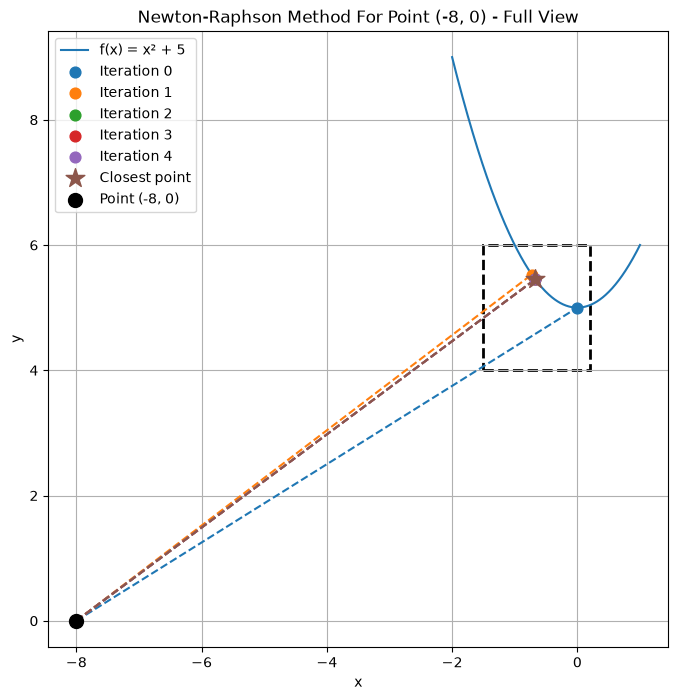

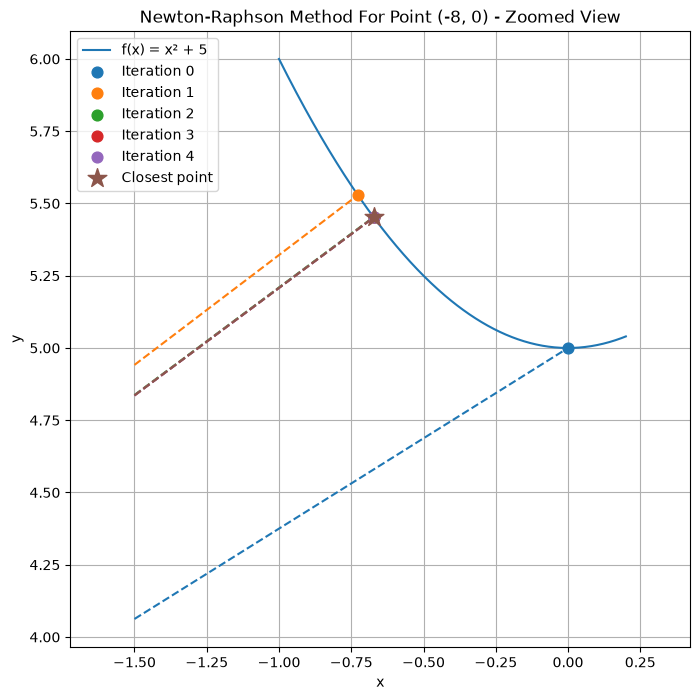

In [38]:
# -----------------------------
# Plot 1: Full view
# -----------------------------

x_values = np.linspace(-2, 1, 400)

plt.figure(figsize=(8, 8))

# Parabola
plt.plot(
    x_values,
    f(x_values),
    label="f(x) = x² + 5"
)

# Newton-Raphson iterations
for i, x_iter in enumerate(iterations):
    y_iter = f(x_iter)

    # Get the color for this iteration
    color = f"C{i}"

    if i == len(iterations) - 1:
        # Last iteration = closest point
        plt.scatter(
            x_iter,
            y_iter,
            marker="*",
            s=200,
            color=color,
            label="Closest point",
            zorder=4
        )
    else:
        plt.scatter(
            x_iter,
            y_iter,
            s=60,
            color=color,
            label=f"Iteration {i}",
            zorder=3
        )

    plt.plot(
        [x0, x_iter],
        [y0, y_iter],
        "--",
        color=color
    )

# Original point — plot last
plt.scatter(
    x0, y0,
    s=100,
    label=f"Point ({x0}, {y0})",
    zorder=5,
    color="black"
)

# Box showing the zoomed region
from matplotlib.patches import Rectangle

zoom_box = Rectangle(
    (-1.5, 4),      # bottom-left corner
    1.7,            # width
    2,              # height
    fill=False,
    linewidth=2,
    linestyle="--"
)

plt.gca().add_patch(zoom_box)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Newton-Raphson Method For Point ({x0}, {y0}) - Full View")
plt.grid(True)
plt.legend(loc="upper left")
plt.axis("equal")

plt.savefig(
    "media/newton_full.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -----------------------------
# Plot 2: Zoomed view
# -----------------------------
x_values = np.linspace(-1, 0.2, 400)

plt.figure(figsize=(8, 8))

plt.plot(
    x_values,
    f(x_values),
    label="f(x) = x² + 5"
)

for i, x_iter in enumerate(iterations):
    y_iter = f(x_iter)

    # Get the color for this iteration
    color = f"C{i}"

    if i == len(iterations) - 1:
        # Last iteration = closest point
        plt.scatter(
            x_iter,
            y_iter,
            marker="*",
            s=200,
            color=color,
            label="Closest point",
            zorder=4
        )
    else:
        plt.scatter(
            x_iter,
            y_iter,
            s=60,
            color=color,
            label=f"Iteration {i}",
            zorder=3
        )

    # Show only the part of the distance line
    # inside the zoomed region
    x_left = -1.5
    y_left = y0 + (y_iter - y0) * (x_left - x0) / (x_iter - x0)

    plt.plot(
        [x_left, x_iter],
        [y_left, y_iter],
        "--",
        color=color,
    )

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Newton-Raphson Method For Point ({x0}, {y0}) - Zoomed View")
plt.grid(True)
plt.legend(loc="upper left")
plt.axis("equal")

plt.savefig("media/newton_zoomed.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
f = lambda x: 2 * x**3 + x**2 - 3 * x + 7
df = lambda x: 6 * x**2 + 2 * x - 3
ddf = lambda x: 12 * x + 2

x0, y0 = -1, 5

shortest_distance, closest_x, iterations = find_distance_newton(
    x0, y0, f, df, ddf
)

print("Iterations:", iterations)
print("Closest x:", closest_x)
print("Closest point on the curve: (", closest_x, ",", f(closest_x), ")")
print("Shortest distance:", shortest_distance)

Iterations: [0.0, 0.35714285714285715, 0.3939311052589172, 0.394894861692472, 0.3948954506795627, 0.3948954506797818]
Closest x: 0.3948954506795627
Closest point on the curve: ( 0.3948954506795627 , 6.094417966985542 )
Shortest distance: 1.7729873109493222


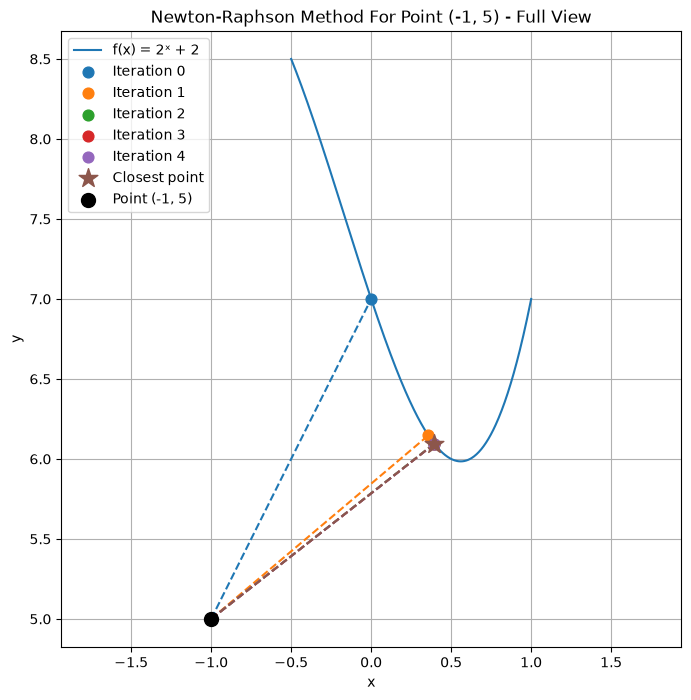

In [40]:
# -----------------------------
# Plot 1: Full view
# -----------------------------

x_values = np.linspace(-0.5, 1, 400)

plt.figure(figsize=(8, 8))

# Function
plt.plot(
    x_values,
    f(x_values),
    label="f(x) = 2ˣ + 2"
)

# Newton-Raphson iterations
for i, x_iter in enumerate(iterations):
    y_iter = f(x_iter)

    color = f"C{i}"

    if i == len(iterations) - 1:
        # Last iteration = closest point
        plt.scatter(
            x_iter,
            y_iter,
            marker="*",
            s=200,
            color=color,
            label="Closest point",
            zorder=4
        )
    else:
        plt.scatter(
            x_iter,
            y_iter,
            s=60,
            color=color,
            label=f"Iteration {i}",
            zorder=3
        )

    plt.plot(
        [x0, x_iter],
        [y0, y_iter],
        "--",
        color=color
    )

# Original point
plt.scatter(
    x0, y0,
    s=100,
    label=f"Point ({x0}, {y0})",
    zorder=5,
    color="black"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Newton-Raphson Method For Point ({x0}, {y0}) - Full View")
plt.grid(True)
plt.legend(loc="upper left")
plt.axis("equal")

plt.savefig(
    "media/newton_full_oth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [41]:
f = lambda x: 2**x + 2
df = lambda x: 2**x * np.log(2)
ddf = lambda x: 2**x * (np.log(2))**2

x0, y0 = 2, 3

shortest_distance, closest_x, iterations = find_distance_newton(
    x0, y0, f, df, ddf
)

print("Iterations:", iterations)
print("Closest x:", closest_x)
print("Closest point on the curve: (", closest_x, ",", f(closest_x), ")")
print("Shortest distance:", shortest_distance)

Iterations: [0.0, np.float64(1.350937842131682), np.float64(1.0036735349104893), np.float64(0.9009555213735779), np.float64(0.8941452665636359), np.float64(0.8941181291608169), np.float64(0.8941181287328213)]
Closest x: 0.8941181291608169
Closest point on the curve: ( 0.8941181291608169 , 3.8584735157463075 )
Shortest distance: 1.3999826747101543


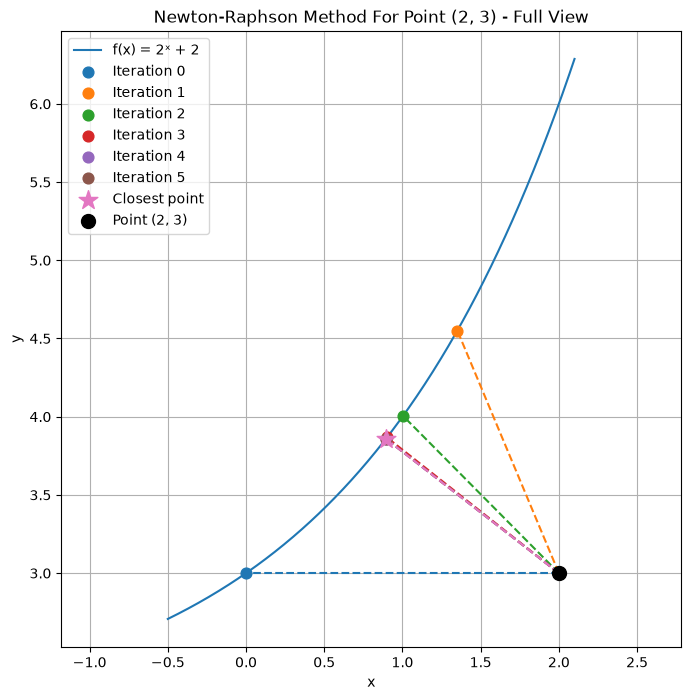

In [42]:
# -----------------------------
# Plot 1: Full view
# -----------------------------

x_values = np.linspace(-0.5, 2.1, 400)

plt.figure(figsize=(8, 8))

# Function
plt.plot(
    x_values,
    f(x_values),
    label="f(x) = 2ˣ + 2"
)

# Newton-Raphson iterations
for i, x_iter in enumerate(iterations):
    y_iter = f(x_iter)

    color = f"C{i}"

    if i == len(iterations) - 1:
        # Last iteration = closest point
        plt.scatter(
            x_iter,
            y_iter,
            marker="*",
            s=200,
            color=color,
            label="Closest point",
            zorder=4
        )
    else:
        plt.scatter(
            x_iter,
            y_iter,
            s=60,
            color=color,
            label=f"Iteration {i}",
            zorder=3
        )

    plt.plot(
        [x0, x_iter],
        [y0, y_iter],
        "--",
        color=color
    )

# Original point
plt.scatter(
    x0, y0,
    s=100,
    label=f"Point ({x0}, {y0})",
    zorder=5,
    color="black"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Newton-Raphson Method For Point ({x0}, {y0}) - Full View")
plt.grid(True)
plt.legend(loc="upper left")
plt.axis("equal")

plt.savefig(
    "media/newton_full_exp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
